**Train Model**

In [1]:
import os
import dotenv
dotenv.load_dotenv()
import sys
sys.path.append(os.getenv('PROJECT_ROOT'))
from src.dataset import MRIDataset
from src.unet3d_dae import UNet3D
import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader, ConcatDataset
import matplotlib.pyplot as plt

torch.manual_seed(32)

##### 1.0 Data Preparation

In [2]:
# Define data path
t1_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T1')
t2_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T2')

# Define dataset 
t1_dataset = MRIDataset(t1_npz_dir, 1)
t2_dataset = MRIDataset(t2_npz_dir, 2)

t1_dataset.files = t1_dataset.files[:250]
t2_dataset.files = t2_dataset.files[:250]

# Split sizes 
min_size = min(len(t1_dataset), len(t2_dataset))
train_size = int(0.7 * min_size)
val_size = int(0.15 * min_size)

# Create train, val, and test sets separately for T1 and T2
t1_train, t1_val, t1_test = random_split(t1_dataset, [train_size, val_size, len(t1_dataset) - train_size - val_size])
t2_train, t2_val, t2_test = random_split(t2_dataset, [train_size, val_size, len(t2_dataset) - train_size - val_size])

# Merge T1 and T2 to get final datasets
train_dataset = ConcatDataset([t1_train, t2_train])
# val_dataset = ConcatDataset([t1_val, t2_val])
# test_dataset = ConcatDataset([t1_test, t2_test])

# Create DataLoaders
batch_size = 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_t1_loader = DataLoader(t1_val, batch_size=batch_size, shuffle=False)
val_t2_loader = DataLoader(t2_val, batch_size=batch_size, shuffle=False)
test_t1_loader = DataLoader(t1_test, batch_size=batch_size, shuffle=False)
test_t2_loader = DataLoader(t2_test, batch_size=batch_size, shuffle=False)

##### 2.0 Setting Up Hyperparameters

In [5]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and move it to the selected device
model = UNet3D().to(device)

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Define number of epochs
n_epochs = 25

# Resume training
resume_epoch = 20
model.load_state_dict(torch.load(
    os.path.join(os.getenv('PROJECT_ROOT'), 'model', 'full_model_weights.pth'),
    map_location=torch.device('cpu')
))

<All keys matched successfully>

##### 3.0 Model Training

In [4]:
# Training loop
training_losses = []
validation_t1_losses = []
validation_t2_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for image, noisy_image, modality, _ in train_loader:
        image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)

        optimizer.zero_grad()
        output = model(noisy_image, modality)
        loss = nn.MSELoss()(output, image)
        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()

    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')
    avg_train_loss = epoch_loss / len(train_loader)
    training_losses.append(avg_train_loss)
    
    # Run Validation
    model.eval()  # Set model to evaluation mode
    val_t1_loss = 0.0
    val_t2_loss = 0.0

    with torch.no_grad():
        for image, noisy_image, modality, _ in val_t1_loader:
            image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = nn.MSELoss()(output, image)
            val_t1_loss += loss.item()
        for image, noisy_image, modality, _ in val_t2_loader:
            image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = nn.MSELoss()(output, image)
            val_t2_loss += loss.item()

    avg_val_t1_loss = val_t1_loss / len(val_t1_loader)
    validation_t1_losses.append(avg_val_t1_loss)
    avg_val_t2_loss = val_t2_loss / len(val_t2_loader)
    validation_t2_losses.append(avg_val_t2_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}] - Train Loss: {avg_train_loss:.6f} - T1 Val Loss: {avg_val_t1_loss:.6f} - T2 Val Loss: {avg_val_t2_loss:.6f}")

Epoch [1/15] - Train Loss: 0.006351 - T1 Val Loss: 0.001485 - T2 Val Loss: 0.002937
Epoch [2/15] - Train Loss: 0.001344 - T1 Val Loss: 0.001081 - T2 Val Loss: 0.000893
Epoch [3/15] - Train Loss: 0.000980 - T1 Val Loss: 0.000899 - T2 Val Loss: 0.000767
Epoch [4/15] - Train Loss: 0.000795 - T1 Val Loss: 0.000700 - T2 Val Loss: 0.000667
Epoch [5/15] - Train Loss: 0.000687 - T1 Val Loss: 0.000865 - T2 Val Loss: 0.000627
Epoch [6/15] - Train Loss: 0.000667 - T1 Val Loss: 0.000719 - T2 Val Loss: 0.000587


KeyboardInterrupt: 

In [4]:
# Training loop
training_losses = []
validation_t1_losses = []
validation_t2_losses = []

for epoch in range(resume_epoch, n_epochs):
    model.train()
    epoch_loss = 0.0

    for image, noisy_image, modality, _ in train_loader:
        image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)

        optimizer.zero_grad()
        output = model(noisy_image, modality)
        loss = nn.MSELoss()(output, image)
        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()

    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')
    avg_train_loss = epoch_loss / len(train_loader)
    training_losses.append(avg_train_loss)
    
    # Run Validation
    model.eval()  # Set model to evaluation mode
    val_t1_loss = 0.0
    val_t2_loss = 0.0

    with torch.no_grad():
        for image, noisy_image, modality, _ in val_t1_loader:
            image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = nn.MSELoss()(output, image)
            val_t1_loss += loss.item()
        for image, noisy_image, modality, _ in val_t2_loader:
            image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = nn.MSELoss()(output, image)
            val_t2_loss += loss.item()

    avg_val_t1_loss = val_t1_loss / len(val_t1_loader)
    validation_t1_losses.append(avg_val_t1_loss)
    avg_val_t2_loss = val_t2_loss / len(val_t2_loader)
    validation_t2_losses.append(avg_val_t2_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}] - Train Loss: {avg_train_loss:.6f} - T1 Val Loss: {avg_val_t1_loss:.6f} - T2 Val Loss: {avg_val_t2_loss:.6f}")

Epoch [8/15] - Train Loss: 0.000621 - T1 Val Loss: 0.000751 - T2 Val Loss: 0.000820
Epoch [9/15] - Train Loss: 0.000549 - T1 Val Loss: 0.000440 - T2 Val Loss: 0.000512
Epoch [10/15] - Train Loss: 0.000447 - T1 Val Loss: 0.000445 - T2 Val Loss: 0.000436
Epoch [11/15] - Train Loss: 0.000509 - T1 Val Loss: 0.000366 - T2 Val Loss: 0.000421
Epoch [12/15] - Train Loss: 0.000425 - T1 Val Loss: 0.000604 - T2 Val Loss: 0.000490
Epoch [13/15] - Train Loss: 0.000433 - T1 Val Loss: 0.000354 - T2 Val Loss: 0.000393
Epoch [14/15] - Train Loss: 0.000357 - T1 Val Loss: 0.000342 - T2 Val Loss: 0.000407
Epoch [15/15] - Train Loss: 0.000371 - T1 Val Loss: 0.000282 - T2 Val Loss: 0.000373


In [5]:
# Training loop
training_losses = []
validation_t1_losses = []
validation_t2_losses = []

for epoch in range(resume_epoch, n_epochs):
    model.train()
    epoch_loss = 0.0

    for image, noisy_image, modality, _ in train_loader:
        image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)

        optimizer.zero_grad()
        output = model(noisy_image, modality)
        loss = nn.MSELoss()(output, image)
        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()

    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')
    avg_train_loss = epoch_loss / len(train_loader)
    training_losses.append(avg_train_loss)
    
    # Run Validation
    model.eval()  # Set model to evaluation mode
    val_t1_loss = 0.0
    val_t2_loss = 0.0

    with torch.no_grad():
        for image, noisy_image, modality, _ in val_t1_loader:
            image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = nn.MSELoss()(output, image)
            val_t1_loss += loss.item()
        for image, noisy_image, modality, _ in val_t2_loader:
            image, noisy_image, modality = image.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = nn.MSELoss()(output, image)
            val_t2_loss += loss.item()

    avg_val_t1_loss = val_t1_loss / len(val_t1_loader)
    validation_t1_losses.append(avg_val_t1_loss)
    avg_val_t2_loss = val_t2_loss / len(val_t2_loader)
    validation_t2_losses.append(avg_val_t2_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}] - Train Loss: {avg_train_loss:.6f} - T1 Val Loss: {avg_val_t1_loss:.6f} - T2 Val Loss: {avg_val_t2_loss:.6f}")

Epoch [16/25] - Train Loss: 0.000379 - T1 Val Loss: 0.000399 - T2 Val Loss: 0.000364
Epoch [17/25] - Train Loss: 0.000354 - T1 Val Loss: 0.000528 - T2 Val Loss: 0.000451
Epoch [18/25] - Train Loss: 0.000326 - T1 Val Loss: 0.000285 - T2 Val Loss: 0.000356
Epoch [19/25] - Train Loss: 0.000308 - T1 Val Loss: 0.000238 - T2 Val Loss: 0.000312
Epoch [20/25] - Train Loss: 0.000289 - T1 Val Loss: 0.000261 - T2 Val Loss: 0.000333


KeyboardInterrupt: 

In [ ]:
# Save model 
torch.save(model.state_dict(), "full_model_weights.pth") 

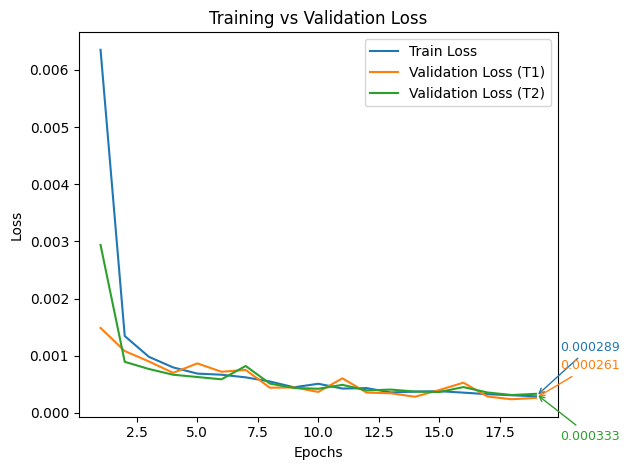

In [4]:
# Visualise training and validation losses
training_losses = [
    0.006351, 0.001344, 0.000980, 0.000795, 0.000687, 0.000667, 0.000621, 0.000549,
    0.000447, 0.000509, 0.000425, 0.000433, 0.000357, 0.000371,
    0.000379, 0.000354, 0.000326, 0.000308, 0.000289
]

validation_t1_losses = [
    0.001485, 0.001081, 0.000899, 0.000700, 0.000865, 0.000719, 0.000751, 0.000440,
    0.000445, 0.000366, 0.000604, 0.000354, 0.000342, 0.000282,
    0.000399, 0.000528, 0.000285, 0.000238, 0.000261
]

validation_t2_losses = [
    0.002937, 0.000893, 0.000767, 0.000667, 0.000627, 0.000587, 0.000820, 0.000512,
    0.000436, 0.000421, 0.000490, 0.000393, 0.000407, 0.000373,
    0.000364, 0.000451, 0.000356, 0.000312, 0.000333
]

epochs = range(1, len(training_losses) + 1)

# Plot the losses
plt.plot(epochs, training_losses, label="Train Loss")
plt.plot(epochs, validation_t1_losses, label="Validation Loss (T1)")
plt.plot(epochs, validation_t2_losses, label="Validation Loss (T2)")

# Annotate final values with arrows pointing to the last data points
plt.annotate(f"{training_losses[-1]:.6f}",
             xy=(epochs[-1], training_losses[-1]),
             xytext=(epochs[-1] + 1, training_losses[-1] + 0.0008),
             arrowprops=dict(arrowstyle="->", color='C0'),
             fontsize=9, color='C0')

plt.annotate(f"{validation_t1_losses[-1]:.6f}",
             xy=(epochs[-1], validation_t1_losses[-1]),
             xytext=(epochs[-1] + 1, validation_t1_losses[-1] + 0.0005),
             arrowprops=dict(arrowstyle="->", color='C1'),
             fontsize=9, color='C1')

plt.annotate(f"{validation_t2_losses[-1]:.6f}",
             xy=(epochs[-1], validation_t2_losses[-1]),
             xytext=(epochs[-1] + 1, validation_t2_losses[-1] - 0.0008),
             arrowprops=dict(arrowstyle="->", color='C2'),
             fontsize=9, color='C2')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.tight_layout()
plt.show()

##### 4.0 Model Testing

In [7]:
# Ensure model is in evaluation mode
model.eval()

# Initialize loss tracking
test_t1_losses = 0.0
test_t2_losses = 0.0

# Loop through testing dataset
with torch.no_grad():
        for t1_image, t1_noisy_image, modality, _ in test_t1_loader:
            t1_image, t1_noisy_image, modality = t1_image.to(device, non_blocking=True), t1_noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            t1_output = model(t1_noisy_image, modality)
            loss = nn.MSELoss()(t1_output, t1_image)
            test_t1_losses += loss.item()
        for t2_image, t2_noisy_image, modality, _ in test_t2_loader:
            t2_image, t2_noisy_image, modality = t2_image.to(device, non_blocking=True), t2_noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            t2_output = model(t2_noisy_image, modality)
            loss = nn.MSELoss()(t2_output, t2_image)
            test_t2_losses += loss.item()

# Compute average validation loss
avg_val_t1_loss = test_t1_losses / len(test_t1_loader)
avg_val_t2_loss = test_t2_losses / len(test_t2_loader)
print(f"T1 Test Loss: {avg_val_t1_loss:.6f} - T2 Test Loss: {avg_val_t2_loss:.6f}")

T1 Test Loss: 0.000278 - T2 Test Loss: 0.000336


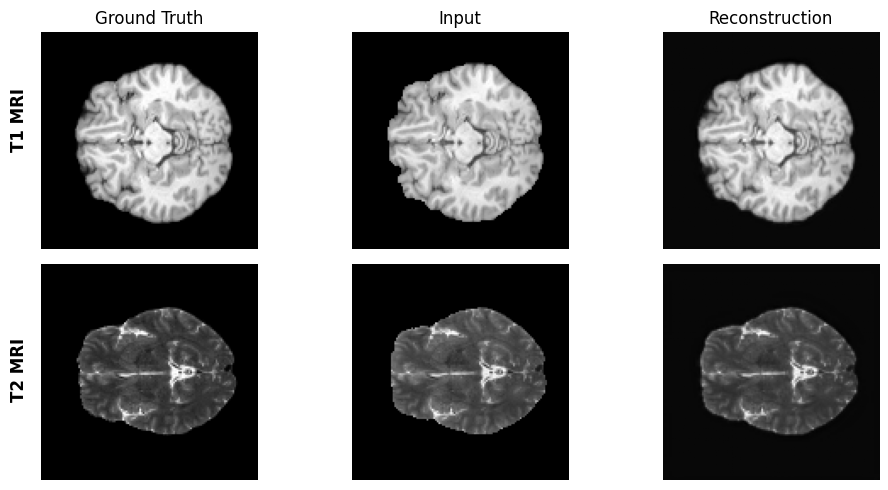

In [8]:
# Visualization of reconstructions 
t1_inputs_np = t1_noisy_image.cpu().numpy()
t1_recon_np = t1_output.cpu().numpy()
t1_original_np = t1_image.cpu().numpy()

t2_inputs_np = t2_noisy_image.cpu().numpy()
t2_recon_np = t2_output.cpu().numpy()
t2_original_np = t2_image.cpu().numpy()

# Create subplots with 2 rows (T1 and T2) and 3 columns (Ground Truth, Input, Reconstruction)
fig, axes = plt.subplots(2, 3, figsize=(10, 5))

# Select the first sample (index 0)
i = 0  

# Extract middle slices along depth
t1_ori_slice = t1_original_np[i, 0, :, :, t1_original_np.shape[-1] // 2]  
t1_mid_slice = t1_inputs_np[i, 0, :, :, t1_inputs_np.shape[-1] // 2]
t1_recon_slice = t1_recon_np[i, 0, :, :, t1_recon_np.shape[-1] // 2]

t2_ori_slice = t2_original_np[i, 0, :, :, t2_original_np.shape[-1] // 2]
t2_mid_slice = t2_inputs_np[i, 0, :, :, t2_inputs_np.shape[-1] // 2]
t2_recon_slice = t2_recon_np[i, 0, :, :, t2_recon_np.shape[-1] // 2]

# Plot T1 slices (row 0)
axes[0, 0].imshow(t1_ori_slice, cmap="gray")  
axes[0, 1].imshow(t1_mid_slice, cmap="gray")  
axes[0, 2].imshow(t1_recon_slice, cmap="gray")  

# Plot T2 slices (row 1)
axes[1, 0].imshow(t2_ori_slice, cmap="gray")  
axes[1, 1].imshow(t2_mid_slice, cmap="gray")  
axes[1, 2].imshow(t2_recon_slice, cmap="gray")  

# Remove axis labels
for row in range(2):
    for col in range(3):
        axes[row, col].axis("off")

# Set column titles
axes[0, 0].set_title("Ground Truth")
axes[0, 1].set_title("Input")
axes[0, 2].set_title("Reconstruction")

# Add row labels (T1 and T2) using fig.text()
fig.text(0.05, 0.75, "T1 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)
fig.text(0.05, 0.25, "T2 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)

plt.tight_layout()
plt.show()